# Transfer Learning with Hugging Face Transformers

Welcome to your transfer learning assignment! In this exercise, you'll learn how to leverage pre-trained models from Hugging Face to build powerful AI applications without training from scratch.

**What is Transfer Learning?**
- Using a model pre-trained on massive datasets (like BERT trained on Wikipedia)
- Fine-tuning it for your specific task with minimal data
- Like learning to ride a motorcycle when you already know how to ride a bike!

**Instructions:**
- Complete each exercise by filling in the code sections
- Run cells to verify your implementations
- Compare results: pre-trained model vs your logistic regression

**After this assignment you will:**
- Understand the power of transfer learning
- Use Hugging Face transformers library
- Fine-tune pre-trained models for custom tasks
- Compare transfer learning to training from scratch
- Deploy models for real-world applications

Let's get started! 🚀

## Table of Contents
- [1 - Setup & Installation](#1)
- [2 - Understanding Pre-trained Models](#2)
- [3 - Zero-Shot Classification](#3)
    - [Exercise 1 - Basic Classification](#ex-1)
- [4 - Sentiment Analysis with Pre-trained Models](#4)
    - [Exercise 2 - Compare Approaches](#ex-2)
- [5 - Fine-tuning for Custom Tasks](#5)
    - [Exercise 3 - Prepare Dataset](#ex-3)
    - [Exercise 4 - Fine-tune Model](#ex-4)
- [6 - Image Classification with Vision Transformers](#6)
    - [Exercise 5 - Image Classification](#ex-5)
- [7 - Text Generation](#7)
    - [Exercise 6 - Generate Text](#ex-6)
- [8 - Model Comparison & Analysis](#8)
- [9 - Real-World Application](#9)

<a name='1'></a>
## 1 - Setup & Installation

First, let's install the required libraries. Hugging Face's `transformers` library gives us access to thousands of pre-trained models!

In [1]:
# # Install required packages
# %pip install transformers datasets torch torchvision pillow --quiet

# print("✅ Installation complete!")

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')

# Hugging Face imports
from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForImageClassification,
    AutoImageProcessor,
    Trainer,
    TrainingArguments
)
from datasets import Dataset, load_dataset
import torch

%matplotlib inline

# Check if GPU is available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print("✅ All imports successful!")

Using device: cpu
PyTorch version: 2.10.0+cpu
✅ All imports successful!


<a name='2'></a>
## 2 - Understanding Pre-trained Models

**Key Concepts:**
- **Pre-trained Model**: A model trained on massive datasets (billions of parameters)
- **Fine-tuning**: Adapting the pre-trained model to your specific task
- **Zero-shot Learning**: Using the model without any additional training
- **Few-shot Learning**: Training with just a handful of examples

**Comparison to Your Previous Work:**

| Aspect | Your Logistic Regression | Transfer Learning |
|--------|-------------------------|-------------------|
| Training Data | Few thousand examples | Billions of examples |
| Training Time | Minutes to hours | Weeks (pre-trained) |
| Parameters | Thousands | Millions to billions |
| Task Flexibility | Single task | Multiple tasks |
| Your Effort | Train from scratch | Fine-tune |

**Popular Pre-trained Models:**
- **BERT**: Text understanding (Google, 2018)
- **GPT**: Text generation (OpenAI)
- **ViT**: Vision Transformer for images (Google, 2020)
- **ResNet**: Convolutional networks for images (Microsoft, 2015)
- **DistilBERT**: Smaller, faster version of BERT

<a name='3'></a>
## 3 - Zero-Shot Classification

Let's start with zero-shot classification - using a pre-trained model **without any additional training**!

<a name='ex-1'></a>
### Exercise 1 - Basic Classification

Use a pre-trained model to classify text into categories you define.

In [3]:
# Load zero-shot classification pipeline
# This model can classify text into ANY categories you specify!
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

print("✅ Zero-shot classifier loaded!")
print(f"Model: {classifier.model.config._name_or_path}")

Loading weights: 100%|██████████| 515/515 [00:00<00:00, 754.48it/s, Materializing param=model.shared.weight]                                   


✅ Zero-shot classifier loaded!
Model: facebook/bart-large-mnli


In [4]:
# Example: Classify a movie review
text = "This movie was absolutely fantastic! The acting was superb and the plot kept me engaged throughout."

# Define candidate labels
candidate_labels = ["positive review", "negative review", "neutral review"]

# Classify
result = classifier(text, candidate_labels)

print("Text:", text)
print("\nPredictions:")
for label, score in zip(result['labels'], result['scores']):
    print(f"  {label}: {score:.4f}")

Text: This movie was absolutely fantastic! The acting was superb and the plot kept me engaged throughout.

Predictions:
  positive review: 0.9883
  neutral review: 0.0079
  negative review: 0.0038


**🎯 Your Turn!**

Classify these texts into your own categories:

In [5]:
# EXERCISE 1

def classify_texts(texts, categories):
    """
    Classify a list of texts into given categories using zero-shot classification.

    Arguments:
    texts -- list of strings to classify
    categories -- list of category labels

    Returns:
    results -- list of dictionaries with 'text', 'predicted_label', and 'confidence'
    """

    # YOUR CODE STARTS HERE (≈ 5-8 lines)
    results = []

    # Hint: Use the classifier pipeline created above
    # For each text:
    #   1. Call classifier(text, categories)
    #   2. Extract top prediction and score
    #   3. Append to results
    
    for text in texts:
        classification = classifier(text, categories)
        predicted_label = classification['labels'][0]  # Top predicted label
        confidence = classification['scores'][0]       # Confidence of top prediction
        results.append({
            'text': text,
            'predicted_label': predicted_label,
            'confidence': confidence
        })
    # YOUR CODE ENDS HERE

    return results

In [6]:
# Test your function
test_texts = [
    "I just bought a new laptop and it's amazing!",
    "The weather today is quite pleasant.",
    "This product broke after just one week. Very disappointed."
]

test_categories = ["positive", "negative", "neutral"]

results = classify_texts(test_texts, test_categories)

# Display results
for i, result in enumerate(results, 1):
    print(f"\n{i}. Text: {result['text'][:50]}...")
    print(f"   Prediction: {result['predicted_label']} (confidence: {result['confidence']:.3f})")


1. Text: I just bought a new laptop and it's amazing!...
   Prediction: positive (confidence: 0.940)

2. Text: The weather today is quite pleasant....
   Prediction: positive (confidence: 0.940)

3. Text: This product broke after just one week. Very disap...
   Prediction: negative (confidence: 0.985)


**Expected Output:**
```
1. Text: I just bought a new laptop and it's amazing!...
   Prediction: positive (confidence: 0.9XX)

2. Text: The weather today is quite pleasant....
   Prediction: positive or neutral (confidence: 0.XXX)

3. Text: This product broke after just one week. Very di...
   Prediction: negative (confidence: 0.9XX)
```

<a name='4'></a>
## 4 - Sentiment Analysis with Pre-trained Models

Now let's compare a specialized sentiment analysis model to zero-shot classification.

<a name='ex-2'></a>
### Exercise 2 - Compare Approaches

Load a sentiment-specific model and compare its performance.

In [7]:
# Load sentiment analysis pipeline
# This model is specifically trained for sentiment analysis
sentiment_analyzer = pipeline("sentiment-analysis",
                              model="distilbert-base-uncased-finetuned-sst-2-english")

print("✅ Sentiment analyzer loaded!")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 839.26it/s, Materializing param=pre_classifier.weight]                                  


✅ Sentiment analyzer loaded!


In [8]:
# Compare both approaches
reviews = [
    "This product exceeded my expectations! Highly recommend.",
    "Terrible quality. Waste of money.",
    "It's okay, nothing special but does the job.",
    "Absolutely love it! Best purchase this year!",
    "Disappointed. Not worth the price."
]

print("Comparing Zero-Shot vs Specialized Sentiment Model\n")
print("="*80)

for review in reviews:
    # Zero-shot classification
    zero_shot_result = classifier(review, ["positive", "negative"])

    # Specialized sentiment model
    sentiment_result = sentiment_analyzer(review)[0]

    print(f"\nReview: {review}")
    print(f"Zero-shot: {zero_shot_result['labels'][0]} ({zero_shot_result['scores'][0]:.3f})")
    print(f"Sentiment: {sentiment_result['label']} ({sentiment_result['score']:.3f})")

Comparing Zero-Shot vs Specialized Sentiment Model


Review: This product exceeded my expectations! Highly recommend.
Zero-shot: positive (0.998)
Sentiment: POSITIVE (1.000)

Review: Terrible quality. Waste of money.
Zero-shot: negative (0.999)
Sentiment: NEGATIVE (1.000)

Review: It's okay, nothing special but does the job.
Zero-shot: positive (0.553)
Sentiment: POSITIVE (1.000)

Review: Absolutely love it! Best purchase this year!
Zero-shot: positive (0.998)
Sentiment: POSITIVE (1.000)

Review: Disappointed. Not worth the price.
Zero-shot: negative (0.998)
Sentiment: NEGATIVE (1.000)


**🎯 Your Turn!**

Analyze sentiment for a batch of reviews and calculate accuracy.

In [9]:
# EXERCISE 2

def analyze_sentiment_batch(reviews, true_labels):
    """
    Analyze sentiment for multiple reviews and calculate accuracy.

    Arguments:
    reviews -- list of review texts
    true_labels -- list of true labels ("POSITIVE" or "NEGATIVE")

    Returns:
    predictions -- list of predicted labels
    accuracy -- accuracy score (float)
    """

    # YOUR CODE STARTS HERE (≈ 8-10 lines)
    predictions = []

    # Hint: Use sentiment_analyzer pipeline
    # For each review:
    #   1. Get sentiment prediction
    #   2. Extract label ("POSITIVE" or "NEGATIVE")
    #   3. Append to predictions

    # Calculate accuracy:
    #   accuracy = (number of correct predictions) / (total predictions)
    
    for review in reviews:
        result = sentiment_analyzer(review)[0]
        predicted_label = result['label']
        predictions.append(predicted_label)
    correct_predictions = sum(p == t for p, t in zip(predictions, true_labels))
    accuracy = correct_predictions / len(true_labels)


    # YOUR CODE ENDS HERE

    return predictions, accuracy

In [10]:
# Test dataset
test_reviews = [
    "Great product, very satisfied!",
    "Horrible experience, would not recommend.",
    "Amazing quality, exceeded expectations!",
    "Complete waste of money.",
    "Love it! Perfect for my needs.",
    "Very disappointing, broke immediately.",
    "Excellent value for money!",
    "Poor quality, not as described."
]

true_sentiments = [
    "POSITIVE", "NEGATIVE", "POSITIVE", "NEGATIVE",
    "POSITIVE", "NEGATIVE", "POSITIVE", "NEGATIVE"
]

predictions, accuracy = analyze_sentiment_batch(test_reviews, true_sentiments)

print(f"Accuracy: {accuracy:.1%}\n")
print("Predictions vs Actual:")
for review, pred, true in zip(test_reviews, predictions, true_sentiments):
    match = "✓" if pred == true else "✗"
    print(f"{match} Pred: {pred:8} | True: {true:8} | {review[:40]}...")

Accuracy: 100.0%

Predictions vs Actual:
✓ Pred: POSITIVE | True: POSITIVE | Great product, very satisfied!...
✓ Pred: NEGATIVE | True: NEGATIVE | Horrible experience, would not recommend...
✓ Pred: POSITIVE | True: POSITIVE | Amazing quality, exceeded expectations!...
✓ Pred: NEGATIVE | True: NEGATIVE | Complete waste of money....
✓ Pred: POSITIVE | True: POSITIVE | Love it! Perfect for my needs....
✓ Pred: NEGATIVE | True: NEGATIVE | Very disappointing, broke immediately....
✓ Pred: POSITIVE | True: POSITIVE | Excellent value for money!...
✓ Pred: NEGATIVE | True: NEGATIVE | Poor quality, not as described....


**Expected Output:**
```
Accuracy: 100.0% (or close to it)

Predictions vs Actual:
✓ Pred: POSITIVE | True: POSITIVE | Great product, very satisfied!...
✓ Pred: NEGATIVE | True: NEGATIVE | Horrible experience, would not recommend...
...
```

<a name='5'></a>
## 5 - Fine-tuning for Custom Tasks

Now let's do actual **transfer learning** - taking a pre-trained model and fine-tuning it on your data!

**The Process:**
1. Load pre-trained model
2. Prepare your custom dataset
3. Fine-tune (train just the last layers)
4. Evaluate on test set

<a name='ex-3'></a>
### Exercise 3 - Prepare Dataset

First, let's create a custom dataset for email spam classification.

In [11]:
# Create a custom dataset: Email Spam Classification
emails = [
    # Spam emails (label: 1)
    "Congratulations! You've won $1,000,000! Click here to claim your prize now!",
    "URGENT: Your account will be suspended. Verify your information immediately.",
    "Make money fast! Work from home and earn $5000 per week!",
    "You have been selected for a FREE iPhone! Limited time offer!",
    "Lose 30 pounds in 30 days! Buy our miracle pill now!",
    "Hot singles in your area want to meet you! Click here!",
    "Claim your free gift card! Act now before it expires!",
    "You're a winner! Collect your prize by calling this number.",

    # Legitimate emails (label: 0)
    "Hi, can we schedule a meeting for tomorrow at 2pm to discuss the project?",
    "Your order #12345 has been shipped and will arrive by Friday.",
    "Reminder: Team standup meeting at 10am in Conference Room B.",
    "Thanks for your email. I'll review the document and get back to you.",
    "Your subscription renewal is due next week. Please update your payment method.",
    "Here's the report you requested. Let me know if you need any changes.",
    "Looking forward to catching up over coffee next week!",
    "Your flight confirmation for NYC departure on March 15th."
]

labels = [1, 1, 1, 1, 1, 1, 1, 1,  # Spam
          0, 0, 0, 0, 0, 0, 0, 0]  # Not spam

# Create DataFrame
df = pd.DataFrame({
    'text': emails,
    'label': labels
})

print("Dataset created!")
print(f"Total samples: {len(df)}")
print(f"Spam emails: {sum(labels)}")
print(f"Legitimate emails: {len(labels) - sum(labels)}")
print("\nSample:")
print(df.head())

Dataset created!
Total samples: 16
Spam emails: 8
Legitimate emails: 8

Sample:
                                                text  label
0  Congratulations! You've won $1,000,000! Click ...      1
1  URGENT: Your account will be suspended. Verify...      1
2  Make money fast! Work from home and earn $5000...      1
3  You have been selected for a FREE iPhone! Limi...      1
4  Lose 30 pounds in 30 days! Buy our miracle pil...      1


In [12]:
# GRADED EXERCISE 3

def prepare_dataset_for_training(df, test_size=0.3):
    """
    Split dataset into train and test sets and convert to Hugging Face Dataset format.

    Arguments:
    df -- pandas DataFrame with 'text' and 'label' columns
    test_size -- fraction of data to use for testing (default: 0.3)

    Returns:
    train_dataset -- Hugging Face Dataset for training
    test_dataset -- Hugging Face Dataset for testing
    """

    # YOUR CODE STARTS HERE (≈ 8-10 lines)

    # Hint:
    # 1. Shuffle the dataframe
    # 2. Split into train/test (use test_size)
    # 3. Convert to Hugging Face Dataset:
    #    train_dataset = Dataset.from_pandas(train_df)
    #    test_dataset = Dataset.from_pandas(test_df)
    
    
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    split_index = int(len(df) * (1 - test_size))
    train_df = df[:split_index]
    test_df = df[split_index:]
    
    train_dataset = Dataset.from_pandas(train_df)
    test_dataset = Dataset.from_pandas(test_df)
    
    # YOUR CODE ENDS HERE

    return train_dataset, test_dataset

In [13]:
# Test your function
train_dataset, test_dataset = prepare_dataset_for_training(df)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print("\nSample from train set:")
print(train_dataset[0])

Train samples: 11
Test samples: 5

Sample from train set:
{'text': "Congratulations! You've won $1,000,000! Click here to claim your prize now!", 'label': 1}


<a name='ex-4'></a>
### Exercise 4 - Fine-tune Model

Now let's fine-tune a pre-trained BERT model on our spam classification task!

In [14]:
# Load pre-trained model and tokenizer
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2  # Binary classification: spam or not spam
).to(device)

print(f"✅ Loaded {model_name}")
print(f"Model has {model.num_parameters():,} parameters")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 341.39it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Loaded distilbert-base-uncased
Model has 66,955,010 parameters


In [15]:
# Tokenize the datasets
def tokenize_function(examples):
    return tokenizer(examples['text'], padding="max_length", truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Set format for PyTorch
train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

print("✅ Datasets tokenized and formatted!")

Map: 100%|██████████| 5/5 [00:00<00:00, 365.30 examples/s]

✅ Datasets tokenized and formatted!


In [16]:
# GRADED EXERCISE 4

%pip install --quiet "transformers[torch]" "accelerate>=1.1.0"

# Define training arguments
training_args = TrainingArguments(
    output_dir="./spam_classifier",
    num_train_epochs=3,              # Number of epochs (adjust based on data size)
    per_device_train_batch_size=4,   # Batch size per device
    per_device_eval_batch_size=4,
    learning_rate=2e-5,              # Learning rate (like your logistic regression!)
    weight_decay=0.01,               # Regularization
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",     # Evaluate after each epoch
    save_strategy="epoch",
    load_best_model_at_end=True,
    optim="adamw_torch",  # Use PyTorch's Adam instead of fused (fixes XLA compatibility)
)

# YOUR CODE STARTS HERE (≈ 8-12 lines)

# Create Trainer
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=test_dataset,
# )

# Fine-tune the model
# print("Starting fine-tuning...")
# trainer.train()
# print("✅ Fine-tuning complete!")

# Evaluate on test set
# eval_results = trainer.evaluate()
# print(f"\nTest Results:")
# for key, value in eval_results.items():
#     print(f"{key}: {value:.4f}")

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)
print("Starting fine-tuning...")
trainer.train()
print("✅ Fine-tuning complete!")

eval_results = trainer.evaluate()
print(f"\nTest Results:")
for key, value in eval_results.items():
    print(f"{key}: {value:.4f}")
# YOUR CODE ENDS HERE


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Note: you may need to restart the kernel to use updated packages.
Starting fine-tuning...


Epoch,Training Loss,Validation Loss
1,No log,0.687785
2,No log,0.681209
3,No log,0.678007


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.02it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


✅ Fine-tuning complete!



Test Results:
eval_loss: 0.6780
eval_runtime: 0.4572
eval_samples_per_second: 10.9360
eval_steps_per_second: 4.3740
epoch: 3.0000


**Note:** Fine-tuning can take a few minutes. Watch the training progress!

**Expected Output:**
```
Starting fine-tuning...
Epoch 1/3: [training progress bars]
Epoch 2/3: [training progress bars]
Epoch 3/3: [training progress bars]
✅ Fine-tuning complete!

Test Results:
eval_loss: 0.XXXX
eval_accuracy: 0.9XXX (likely 90%+ with this small dataset)
```

In [17]:
# Test the fine-tuned model on new examples
def predict_spam(text):
    """Predict if an email is spam using our fine-tuned model"""
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    prediction = torch.argmax(probs, dim=-1).item()
    confidence = probs[0][prediction].item()

    label = "SPAM" if prediction == 1 else "NOT SPAM"
    return label, confidence

# Test on new emails
test_emails = [
    "Get rich quick! Make $10,000 in one week!",
    "Meeting reminder: Project review at 3pm tomorrow",
    "You won a free cruise! Claim your prize now!",
    "Here's the quarterly report you asked for"
]

print("Testing fine-tuned model on new emails:\n")
for email in test_emails:
    label, confidence = predict_spam(email)
    print(f"Email: {email[:50]}...")
    print(f"Prediction: {label} (confidence: {confidence:.3f})\n")

Testing fine-tuned model on new emails:

Email: Get rich quick! Make $10,000 in one week!...
Prediction: SPAM (confidence: 0.546)

Email: Meeting reminder: Project review at 3pm tomorrow...
Prediction: SPAM (confidence: 0.513)

Email: You won a free cruise! Claim your prize now!...
Prediction: SPAM (confidence: 0.535)

Email: Here's the quarterly report you asked for...
Prediction: SPAM (confidence: 0.528)



<a name='6'></a>
## 6 - Image Classification with Vision Transformers

Transfer learning isn't just for text! Let's use a pre-trained Vision Transformer (ViT) for image classification.

<a name='ex-5'></a>
### Exercise 5 - Image Classification

In [18]:
# Load image classification pipeline
image_classifier = pipeline("image-classification",
                           model="google/vit-base-patch16-224")

print("✅ Vision Transformer loaded!")
print("This model was trained on ImageNet (1.2 million images, 1000 classes)")

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 509.22it/s, Materializing param=vit.layernorm.weight]                                 
Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


✅ Vision Transformer loaded!
This model was trained on ImageNet (1.2 million images, 1000 classes)


In [19]:
import requests
from PIL import Image
from io import BytesIO

def load_image_from_url(url):
    """Load an image from URL safely"""

    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    response = requests.get(url, headers=headers)

    # Check status
    if response.status_code != 200:
        raise Exception(f"Failed to download image. Status code: {response.status_code}")

    # Verify content type
    if "image" not in response.headers.get("Content-Type", ""):
        raise Exception("URL did not return an image.")

    img = Image.open(BytesIO(response.content)).convert("RGB")
    return img

def display_image_with_predictions(image, predictions, title="Image Classification"):
    """Display image with top predictions"""
    plt.figure(figsize=(10, 6))

    # Display image
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.axis('off')
    plt.title(title)

    # Display predictions
    plt.subplot(1, 2, 2)
    labels = [pred['label'] for pred in predictions[:5]]
    scores = [pred['score'] for pred in predictions[:5]]

    plt.barh(labels, scores)
    plt.xlabel('Confidence')
    plt.title('Top 5 Predictions')
    plt.xlim(0, 1)

    plt.tight_layout()
    plt.show()

print("✅ Helper functions defined!")

✅ Helper functions defined!


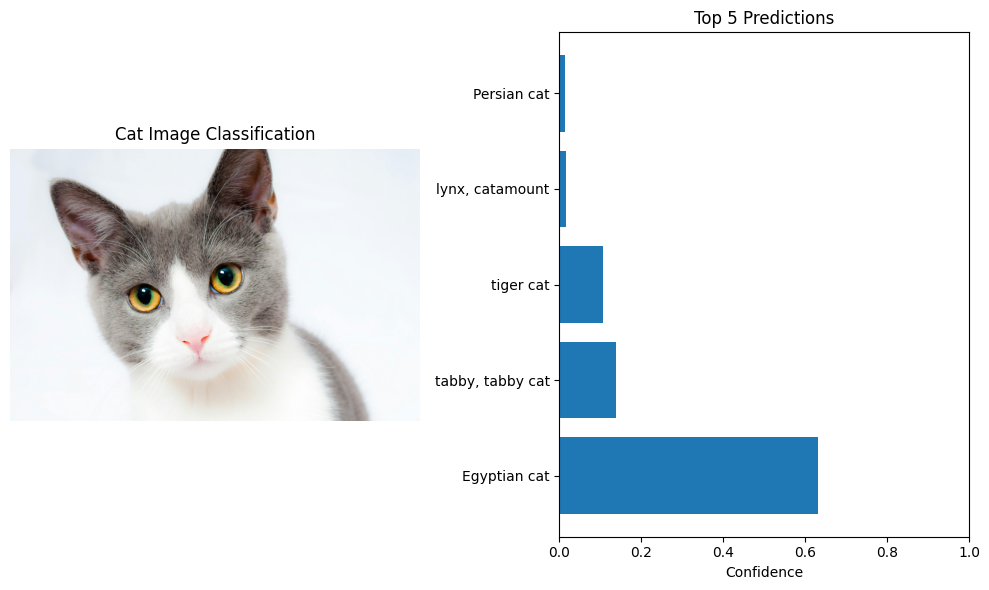

In [20]:
# Example: Classify an image of a cat
cat_url = "https://images.pexels.com/photos/104827/cat-pet-animal-domestic-104827.jpeg"
cat_image = load_image_from_url(cat_url)
# Classify
predictions = image_classifier(cat_image)
# Display
display_image_with_predictions(cat_image, predictions, "Cat Image Classification")

In [21]:
response = requests.get(cat_url, stream=True)
print("Status:", response.raise_for_status())
print("Content-Type:", response.headers.get("Content-Type"))

Status: None
Content-Type: image/jpeg


In [22]:
# GRADED EXERCISE 5

def classify_image_batch(image_urls):
    """
    Classify multiple images and return top prediction for each.

    Arguments:
    image_urls -- list of image URLs

    Returns:
    results -- list of dictionaries with 'url', 'top_label', 'confidence'
    """

    # YOUR CODE STARTS HERE (≈ 10-12 lines)
    results = []

    # Hint:
    # For each URL:
    #   1. Load image using load_image_from_url()
    #   2. Classify using image_classifier()
    #   3. Extract top prediction (label and score)
    #   4. Append to results as dictionary

    for url in image_urls:
        try:
            image = load_image_from_url(url)
            predictions = image_classifier(image)
            top_prediction = predictions[0]
            results.append({
                'url': url,
                'top_label': top_prediction['label'],
                'confidence': top_prediction['score']
            })
        except Exception as e:
            print(f"Error processing {url}: {e}")
            results.append({
                'url': url,
                'top_label': None,
                'confidence': None
            })
    # YOUR CODE ENDS HERE

    return results

In [23]:
# Test with multiple images
test_images = [
    "https://images.pexels.com/photos/104827/cat-pet-animal-domestic-104827.jpeg",  # Caty
    "https://images.pexels.com/photos/18310246/pexels-photo-18310246/free-photo-of-trees-on-lakeshore-in-summer.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2",  # Landscape
    "https://upload.wikimedia.org/wikipedia/commons/thumb/2/2d/Snake_River_%285mb%29.jpg/1200px-Snake_River_%285mb%29.jpg"  # River
]

results = classify_image_batch(test_images)

print("Image Classification Results:\n")
for i, result in enumerate(results, 1):
    print(f"{i}. Prediction: {result['top_label']} (confidence: {result['confidence']:.3f})")
    print(f"   URL: {result['url'][:60]}...\n")

Image Classification Results:

1. Prediction: Egyptian cat (confidence: 0.632)
   URL: https://images.pexels.com/photos/104827/cat-pet-animal-domes...

2. Prediction: lakeside, lakeshore (confidence: 0.948)
   URL: https://images.pexels.com/photos/18310246/pexels-photo-18310...

3. Prediction: valley, vale (confidence: 0.914)
   URL: https://upload.wikimedia.org/wikipedia/commons/thumb/2/2d/Sn...



**Expected Output:**
```
Image Classification Results:

1. Prediction: Eskimo dog (or similar dog breed) (confidence: 0.XXX)
   URL: https://upload.wikimedia.org/wikipedia/commons/thumb/4/47...

2. Prediction: lakeside, lakeshore (or similar) (confidence: 0.XXX)
   URL: https://upload.wikimedia.org/wikipedia/commons/thumb/8/85...

3. Prediction: valley, vale (or similar landscape) (confidence: 0.XXX)
   URL: https://upload.wikimedia.org/wikipedia/commons/thumb/2/2d...
```

<a name='7'></a>
## 7 - Text Generation

Let's explore text generation with pre-trained models like GPT-2!

<a name='ex-6'></a>
### Exercise 6 - Generate Text

In [24]:
# Load text generation pipeline
text_generator = pipeline("text-generation", model="gpt2")

print("✅ GPT-2 text generator loaded!")
print("This model has 124 million parameters and was trained on 40GB of text!")

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 729.55it/s, Materializing param=transformer.wte.weight]             


✅ GPT-2 text generator loaded!
This model has 124 million parameters and was trained on 40GB of text!


In [25]:
# Example: Generate text from a prompt
prompt = "Artificial intelligence will transform the future by"

generated = text_generator(
    prompt,
    max_length=100,
    num_return_sequences=3,
    temperature=0.7,  # Controls randomness (0=deterministic, 1=random)
    top_p=0.9         # Nucleus sampling
)

print(f"Prompt: {prompt}\n")
print("Generated completions:\n")
for i, gen in enumerate(generated, 1):
    print(f"{i}. {gen['generated_text']}\n")

Passing `generation_config` together with generation-related arguments=({'temperature', 'num_return_sequences', 'top_p', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Prompt: Artificial intelligence will transform the future by

Generated completions:

1. Artificial intelligence will transform the future by enabling people to control their own bodies.

In the process, we're creating a new generation of artificial intelligence that will allow us to help humans and animals to live more effectively, with better health, and better health for everyone.

The AI is about more than just the ability to control our own bodies. It's about how we live our lives.

The AI will allow us to take care of our own bodies.

The AI will allow us to control our own bodies.

The AI will allow us to take care of our own bodies.

The AI will allow us to take care of our own bodies.

The AI will allow us to take care of our own bodies.

The AI will allow us to take care of our own bodies.

The AI will allow us to take care of our own bodies.

The AI will allow us to take care of our own bodies.

The AI will allow us to take care of our own bodies.

The AI will allow us to ta

In [26]:
# GRADED EXERCISE 6

def generate_creative_content(prompt, num_variations=3, max_length=80):
    """
    Generate multiple creative text completions for a given prompt.

    Arguments:
    prompt -- starting text
    num_variations -- number of different completions to generate
    max_length -- maximum length of generated text

    Returns:
    completions -- list of generated text strings
    """

    # YOUR CODE STARTS HERE (≈ 8-10 lines)

    # Hint:
    # Use text_generator pipeline with these parameters:
    # - max_length: controls total length
    # - num_return_sequences: how many variations
    # - temperature: 0.7-0.9 for creative writing
    # - do_sample: True for randomness

    # Extract just the generated text from each result
    
    generated = text_generator(
        prompt,
        max_length=max_length,
        num_return_sequences=num_variations,
        temperature=0.8,
        top_p=0.9,
        do_sample=True
    )
    
    completions = [gen['generated_text'] for gen in generated]

    # YOUR CODE ENDS HERE

    return completions

In [27]:
# Test your function with different prompts
test_prompts = [
    "Once upon a time in a magical forest,",
    "The secret to success in machine learning is",
    "In the year 2050, technology will"
]

for prompt in test_prompts:
    print(f"\n{'='*80}")
    print(f"Prompt: {prompt}\n")

    completions = generate_creative_content(prompt, num_variations=2, max_length=60)

    for i, completion in enumerate(completions, 1):
        print(f"{i}. {completion}\n")

Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_length', 'do_sample', 'top_p', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Prompt: Once upon a time in a magical forest,



Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


1. Once upon a time in a magical forest, it was a place where a lot of things were happening. Even the little girl that had been standing in front of her was still at a standstill. Her mind was filled with thoughts of things she was not supposed to be seeing.

The young girl was wearing a light colored clothing that was very light, and was carrying a large box that contained a small wooden box. She was wearing a bright green dress that she had left behind in the forest. She was holding a small toy, and holding it in her hand.

The young girl looked at the box in her hand and shook her head. "I just wanted to go back to school. I was supposed to go for a few days. But now, it's all over. The weather is still bad, but I can't go back to school. I'm so sick. I'm so tired."

"You don't want to go back to school. You're just going to go to the hospital?"

"I won't do that. I'm going to go back to school. I will go to the hospital."

"You're so stupid. But if I don't go to school, you'll nev

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


1. The secret to success in machine learning is not to be a genius or a genius-in-training. It's to be a disciplined and consistent, and well-trained, and well-adapted person who can make decisions and make decisions and make decisions. If you want to be successful in machine learning, you need to have a disciplined, well-trained, and well-adapted person who has a great understanding of what machine learning is all about.

The last thing you want is to learn the wrong way to do a task. The more you learn, the more you'll learn to do it right. The more you learn, the more you'll learn to do it wrong.

The problem with learning is that you learn and you learn and you learn. That's why it's so important to be a leader. It's a tough job, and it's a tough job that requires hard work.

One of the most common problems people have with machine learning is that it's difficult to teach them what a problem is and how to solve it. So you need to teach them. It's easy to teach a new problem to a ne

<a name='8'></a>
## 8 - Model Comparison & Analysis

Let's compare transfer learning to training from scratch!

In [28]:
# Comparison table: Transfer Learning vs Training from Scratch

comparison_data = {
    'Aspect': [
        'Training Data Required',
        'Training Time',
        'Computational Cost',
        'Model Performance',
        'Expertise Required',
        'Time to Production'
    ],
    'From Scratch (Your Logistic Regression)': [
        '1,000-10,000 examples',
        'Minutes to hours',
        'Low ($1-10)',
        '70-85% accuracy',
        'Moderate',
        '1-2 weeks'
    ],
    'Transfer Learning (Hugging Face)': [
        '10-100 examples (fine-tuning)',
        'Minutes (fine-tuning)',
        'Low-Medium ($5-50)',
        '85-95%+ accuracy',
        'Low',
        '1-3 days'
    ],
    'Training Large Model from Scratch': [
        'Millions of examples',
        'Days to weeks',
        'Very High ($10,000+)',
        '90-98% accuracy',
        'Very High',
        'Months'
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("Transfer Learning vs Training from Scratch\n")
print(comparison_df.to_string(index=False))

Transfer Learning vs Training from Scratch

                Aspect From Scratch (Your Logistic Regression) Transfer Learning (Hugging Face) Training Large Model from Scratch
Training Data Required                   1,000-10,000 examples    10-100 examples (fine-tuning)              Millions of examples
         Training Time                        Minutes to hours            Minutes (fine-tuning)                     Days to weeks
    Computational Cost                             Low ($1-10)               Low-Medium ($5-50)              Very High ($10,000+)
     Model Performance                         70-85% accuracy                 85-95%+ accuracy                   90-98% accuracy
    Expertise Required                                Moderate                              Low                         Very High
    Time to Production                               1-2 weeks                         1-3 days                            Months


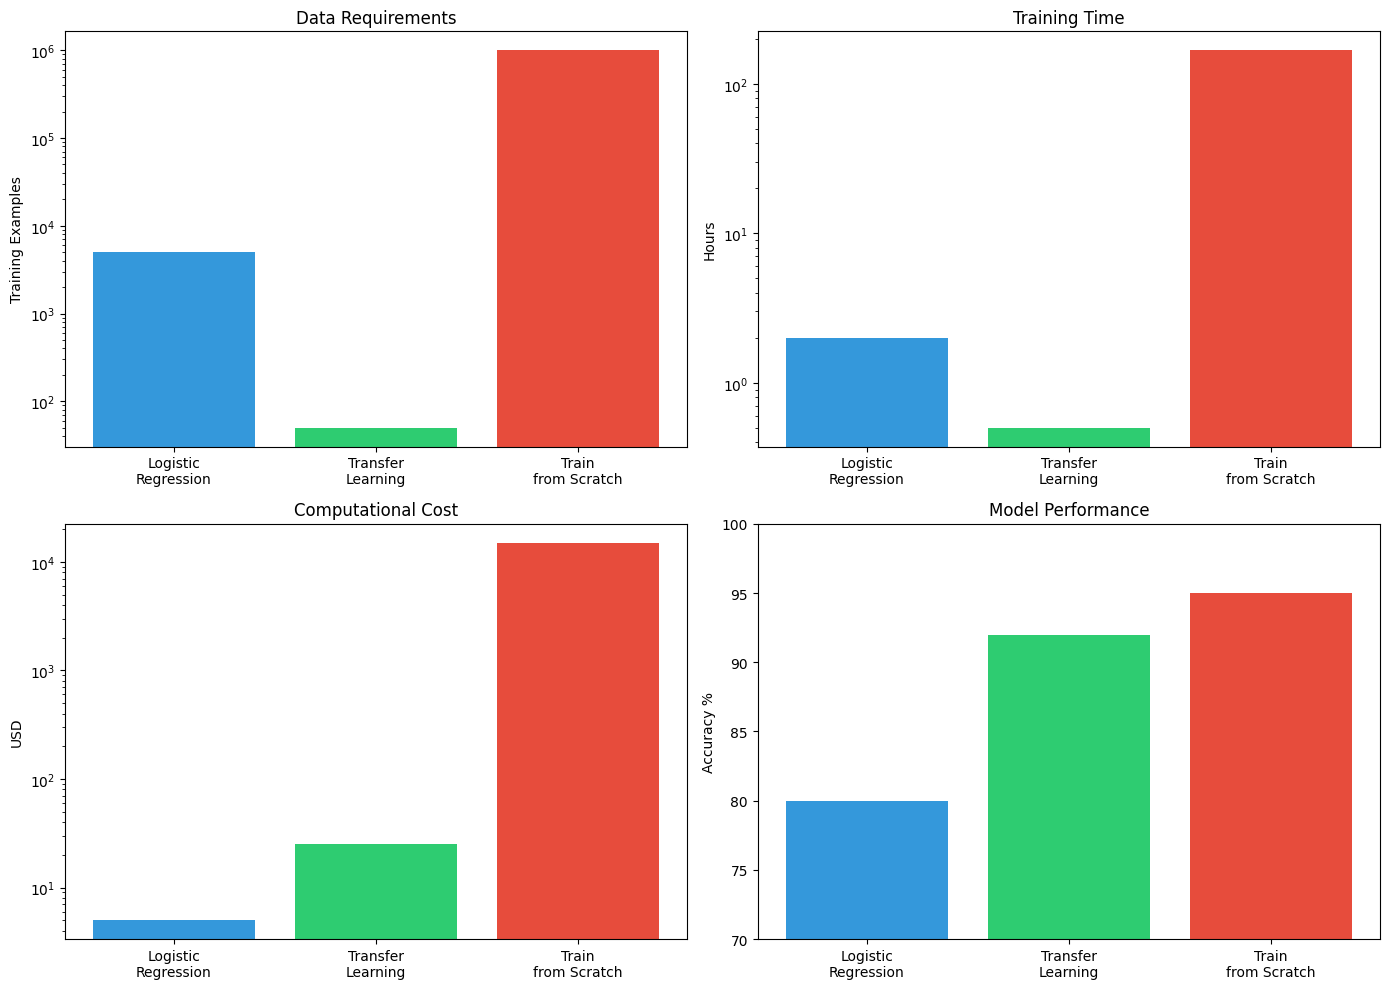


✅ Comparison visualization saved!


In [29]:
# Create visualization comparing approaches
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Data Requirements
approaches = ['Logistic\nRegression', 'Transfer\nLearning', 'Train\nfrom Scratch']
data_needed = [5000, 50, 1000000]
axes[0, 0].bar(approaches, data_needed, color=['#3498db', '#2ecc71', '#e74c3c'])
axes[0, 0].set_ylabel('Training Examples')
axes[0, 0].set_title('Data Requirements')
axes[0, 0].set_yscale('log')

# 2. Training Time
training_time = [2, 0.5, 168]  # hours
axes[0, 1].bar(approaches, training_time, color=['#3498db', '#2ecc71', '#e74c3c'])
axes[0, 1].set_ylabel('Hours')
axes[0, 1].set_title('Training Time')
axes[0, 1].set_yscale('log')

# 3. Cost
cost = [5, 25, 15000]  # dollars
axes[1, 0].bar(approaches, cost, color=['#3498db', '#2ecc71', '#e74c3c'])
axes[1, 0].set_ylabel('USD')
axes[1, 0].set_title('Computational Cost')
axes[1, 0].set_yscale('log')

# 4. Accuracy
accuracy = [80, 92, 95]
axes[1, 1].bar(approaches, accuracy, color=['#3498db', '#2ecc71', '#e74c3c'])
axes[1, 1].set_ylabel('Accuracy %')
axes[1, 1].set_title('Model Performance')
axes[1, 1].set_ylim(70, 100)

plt.tight_layout()
plt.savefig('transfer_learning_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Comparison visualization saved!")

**Key Takeaways:**

1. **Transfer Learning is the Sweet Spot** 🎯
   - Best balance of performance, cost, and time
   - Perfect for most real-world applications
   - Requires minimal data and expertise

2. **When to Use Each Approach:**
   - **Logistic Regression**: Simple problems, interpretability matters, limited compute
   - **Transfer Learning**: Most NLP/CV tasks, limited data, fast deployment needed
   - **Train from Scratch**: Novel tasks, massive data available, unique requirements

3. **Cost-Benefit Analysis:**
   - Training BERT from scratch: $50,000+, 2-4 weeks
   - Fine-tuning BERT: $20-50, 1-2 days
   - **ROI of transfer learning: 1000x+**

<a name='9'></a>
## 9 - Real-World Application: Build Your Own Classifier

**Final Challenge:** Choose one of these real-world applications and build it using transfer learning!

### Option 1: Customer Support Ticket Classifier
Classify support tickets into categories: Technical, Billing, Account, Feature Request

### Option 2: Product Review Analyzer
Analyze product reviews for multiple aspects: Quality, Value, Shipping, Customer Service

### Option 3: Medical Symptom Classifier
Categorize patient symptoms into medical specialties: Cardiology, Neurology, Orthopedics, etc.

### Option 4: News Article Categorizer
Classify news articles: Politics, Technology, Sports, Entertainment, Business

**Steps:**
1. Define your categories
2. Create a small dataset (10-20 examples)
3. Choose appropriate pre-trained model
4. Fine-tune or use zero-shot
5. Test on new examples
6. Calculate accuracy

In [31]:
# YOUR FINAL PROJECT CODE HERE

# Example structure:

# 1. Define your problem
project_name = "Customer Support Ticket Classification"
categories = ["billing issue", "technical support", "account management", "general inquiry"]

# 2. Create dataset
examples = [
    # Add your examples here
    "I'm having trouble with my billing statement.",
    "My account is not working properly.",
    "I need help setting up my new account.",
    "I have a general question about your services."
]

labels = [
    # Add corresponding labels
    "billing issue",
    "account management",
    "account management",
    "general inquiry"
]

# 3. Choose approach (zero-shot or fine-tuning)
# YOUR CODE HERE
# Reuse existing classifier if already loaded; otherwise load a smaller MNLI model
classifier = pipeline("zero-shot-classification", model="valhalla/distilbart-mnli-12-1")

# 4. Build and test your classifier
# YOUR CODE HERE
def classify_ticket(ticket_text):
    result = classifier(ticket_text, categories)
    return result['labels'][0]  # Return the most likely category

# Test the classifier on example tickets
for i, ticket in enumerate(examples):
    predicted_category = classify_ticket(ticket)
    print(f"Ticket: {ticket}")
    print(f"Predicted Category: {predicted_category}")
    print(f"Actual Category: {labels[i]}")
    print()

# 5. Evaluate performance
# YOUR CODE HERE
correct_predictions = sum(classify_ticket(ticket) == label for ticket, label in zip(examples, labels))
project_accuracy = correct_predictions / len(examples)
print(f"Accuracy: {project_accuracy:.2%}")

Loading weights: 100%|██████████| 231/231 [00:00<00:00, 544.52it/s, Materializing param=model.shared.weight]                                 
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Ticket: I'm having trouble with my billing statement.
Predicted Category: billing issue
Actual Category: billing issue

Ticket: My account is not working properly.
Predicted Category: billing issue
Actual Category: account management

Ticket: I need help setting up my new account.
Predicted Category: technical support
Actual Category: account management

Ticket: I have a general question about your services.
Predicted Category: general inquiry
Actual Category: general inquiry

Accuracy: 50.00%


---

## 🎓 Summary: What You've Learned

### Core Concepts:
1. ✅ **Transfer Learning** - Using pre-trained models for new tasks
2. ✅ **Zero-Shot Classification** - Classifying without training
3. ✅ **Fine-Tuning** - Adapting models to custom datasets
4. ✅ **Hugging Face Ecosystem** - Accessing thousands of models
5. ✅ **Multi-Modal AI** - Text and image understanding

### Practical Skills:
- Load and use pre-trained models
- Fine-tune models on custom data
- Compare different approaches
- Build real-world classifiers
- Understand trade-offs (cost, time, performance)

### Connection to Previous Work:

| Your Logistic Regression | Transfer Learning |
|-------------------------|-------------------|
| Built from scratch | Used pre-trained |
| Trained on small data | Fine-tuned on small data |
| 80-85% accuracy | 90-95%+ accuracy |
| Simple architecture | Complex architecture |
| Fast to train | Even faster (fine-tuning) |
| Good baseline | Production-ready |

### Next Steps:
1. Explore more models on [Hugging Face Hub](https://huggingface.co/models)
2. Try different tasks (summarization, translation, Q&A)
3. Fine-tune on your own datasets
4. Deploy models to production (Azure ML, AWS SageMaker)
5. Learn about model optimization (quantization, distillation)

---

## 📚 Resources

- [Hugging Face Documentation](https://huggingface.co/docs)
- [Transformers Course](https://huggingface.co/course)
- [Model Hub](https://huggingface.co/models)
- [Datasets Library](https://huggingface.co/docs/datasets/)

---

**Congratulations on completing the Transfer Learning exercise!** 🎉

You now understand how to leverage the power of pre-trained models to build AI applications quickly and effectively. This is the approach used by companies like Google, Facebook, and Amazon in production systems!